# 02 — Feature Engineering
Resample mixed-frequency data, build lag features, rolling statistics, and save the processed feature matrix.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.features import (
    resample_to_monthly,
    make_stationary,
    make_lag_features,
    make_rolling_features,
    build_feature_matrix,
)

print('Imports OK')

Imports OK


In [2]:
df_raw = pd.read_csv('../data/raw/macro_raw.csv', index_col='date', parse_dates=True)
print(f'Raw shape: {df_raw.shape}')
df_raw.head(3)

Raw shape: (11479, 12)


,gdp,cpi,unemployment,payrolls,claims,indpro,retail,housing,sentiment,yield_curve,m2,ppi
date,,,,,,,,,,,,
1990-01-01,10047.386,127.5,5.4,109196.0,NaN,61.729,NaN,1551.0,93.0,NaN,3166.8,114.9
1990-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.07,NaN,NaN
1990-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.05,NaN,NaN


## Step 1 — Resample to monthly

In [3]:
df_monthly = resample_to_monthly(df_raw)
print(f'Monthly shape: {df_monthly.shape}')
print(f'Date range: {df_monthly.index[0].date()} → {df_monthly.index[-1].date()}')
df_monthly.isnull().sum()

Monthly shape: (438, 12)
Date range: 1990-01-01 → 2026-06-01


gdp              0
cpi              0
unemployment     0
payrolls         0
claims           0
indpro           0
retail          24
housing          0
sentiment        0
yield_curve      0
m2               0
ppi              0
dtype: int64

## Step 2 — Stationarity transform

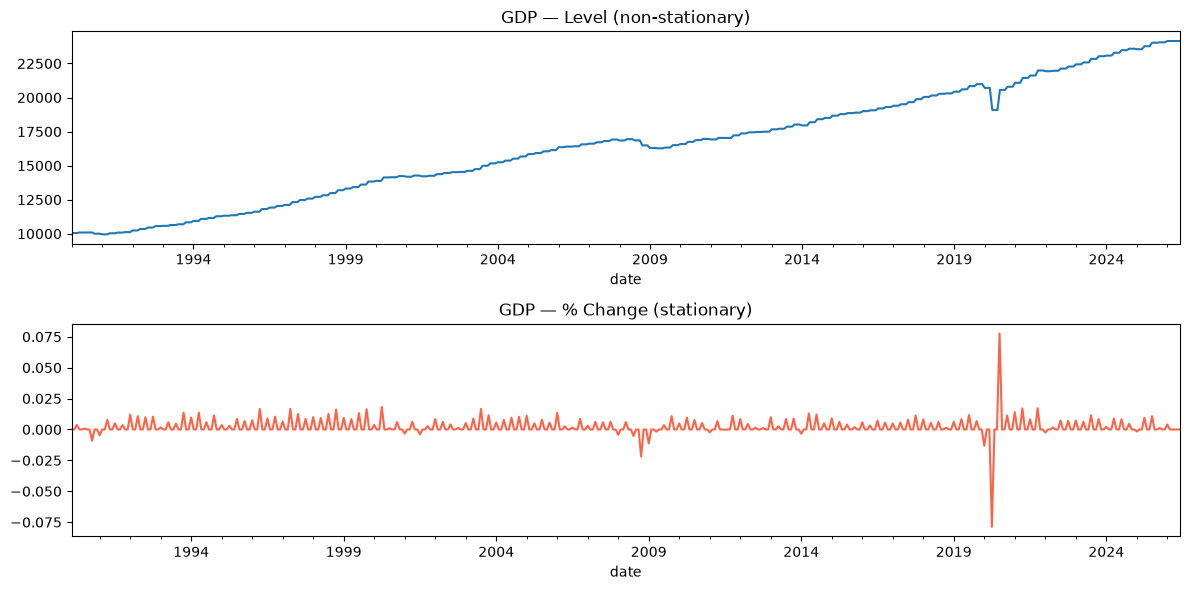

In [4]:
df_stat = make_stationary(df_monthly, method='pct_change')

# Visualize before/after for GDP
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
df_monthly['gdp'].dropna().plot(ax=ax1, title='GDP — Level (non-stationary)')
df_stat['gdp'].dropna().plot(ax=ax2, title='GDP — % Change (stationary)', color='tomato')
plt.tight_layout()
plt.savefig('../outputs/figures/gdp_stationarity.png', dpi=150)
plt.show()

## Step 3 — Lag + rolling features

In [5]:
indicator_cols = [c for c in df_stat.columns if c not in ['gdp', 'cpi', 'unemployment']]

df_feat = make_lag_features(df_stat, lags=[1, 2, 3, 4, 6, 12], cols=indicator_cols)
df_feat = make_rolling_features(df_feat, windows=[3, 6, 12], cols=indicator_cols)

print(f'Feature matrix shape: {df_feat.shape}')
print(f'Total features: {df_feat.shape[1]}')
df_feat.head(3)

Feature matrix shape: (438, 120)
Total features: 120


,gdp,cpi,unemployment,payrolls,claims,indpro,retail,housing,sentiment,yield_curve,...,ppi_roll12_mean,payrolls_roll12_std,claims_roll12_std,indpro_roll12_std,retail_roll12_std,housing_roll12_std,sentiment_roll12_std,yield_curve_roll12_std,m2_roll12_std,ppi_roll12_std
date,,,,,,,,,,,,,,,,,,,,,
1990-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-02-01,0.0,0.003922,-0.018519,0.002198,0.014493,0.009082,NaN,-0.073501,-0.037634,-0.466667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-03-01,0.0,0.004687,-0.018868,0.001864,-0.011429,0.004982,NaN,-0.102992,0.020112,-0.875000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 4 — Build X, y for each target and horizon

In [6]:
targets = ['gdp', 'cpi', 'unemployment']
horizons = [1, 2, 4]

datasets = {}
for target in targets:
    for h in horizons:
        X, y = build_feature_matrix(df_raw, target_col=target, forecast_horizon=h)
        datasets[(target, h)] = (X, y)
        print(f'{target} h={h}: X={X.shape}, y={y.shape}, NaN in y={y.isna().sum()}')

gdp h=1: X=(384, 154), y=(384,), NaN in y=0
gdp h=2: X=(383, 154), y=(383,), NaN in y=0
gdp h=4: X=(381, 154), y=(381,), NaN in y=0
cpi h=1: X=(384, 154), y=(384,), NaN in y=0
cpi h=2: X=(383, 154), y=(383,), NaN in y=0
cpi h=4: X=(381, 154), y=(381,), NaN in y=0
unemployment h=1: X=(384, 154), y=(384,), NaN in y=0
unemployment h=2: X=(383, 154), y=(383,), NaN in y=0
unemployment h=4: X=(381, 154), y=(381,), NaN in y=0


## Step 5 — Save processed data

In [7]:
# Save the monthly stationary frame as the base processed file
df_stat.to_csv('../data/processed/macro_monthly_stationary.csv')
df_feat.to_csv('../data/processed/macro_features.csv')
print('Saved to data/processed/')

Saved to data/processed/
